# Pathway latent factor regularization

This tutorial demonstrates the `PathwayLatentRegularizer` (see `docs/notes/functional_dis_and_similarity.md` for the design note) on a synthetic problem.

**Setup.** We construct a graph of `K=4` disconnected components. Each component is a self-contained \"pathway\" with its own inputs, function nodes, and outputs, so the ground-truth signaling between pathways is zero. We simulate data, add a small number of *spurious* cross-pathway function-to-function edges to the GSNN input graph, and train three models:

1. **Baseline** — vanilla GSNN, MSE loss only.
2. **Regularized** — GSNN + `PathwayLatentRegularizer` with the true pathway membership.
3. **Random-pathway control** — same regularizer, but pathway membership is shuffled. This is the most important sanity check: if it helps interpretability, the regularizer is acting as a generic smoothing prior, not encoding pathway information.

**Evaluation.** Test MSE (sanity), within- vs cross-pathway activation cosine similarity, ARI between learned activation clusters and true pathway labels, and per-edge weight magnitudes for true vs spurious function-function edges.

In [37]:
import math
import copy
import numpy as np
import torch
import networkx as nx
from matplotlib import pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from gsnn.models.GSNN import GSNN
from gsnn.models.PathwayLatentRegularizer import PathwayLatentRegularizer
from gsnn.simulate.simulate import simulate
from gsnn.simulate.nx2pyg import nx2pyg

seed = 1
torch.manual_seed(seed)
np.random.seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {device}")

%load_ext autoreload
%autoreload 2

device = cuda
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build the disconnected-pathway graph

`K=4` independent pathways. Each pathway has 2 inputs, 3 function nodes in a chain, and 2 outputs. There are no edges between pathways in the true graph.

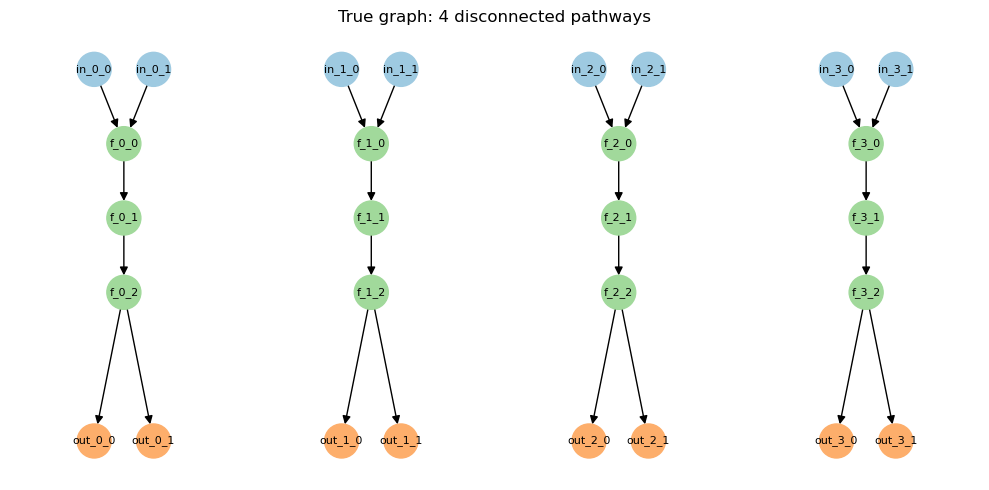

inputs: 8 | functions: 12 | outputs: 8


In [38]:
def build_pathway_graph(K=4, n_in=2, n_func=3, n_out=2):
    G = nx.DiGraph()
    input_nodes, function_nodes, output_nodes = [], [], []
    component_of = {}  # function node name -> pathway index
    pos = {}
    for p in range(K):
        ins = [f"in_{p}_{i}" for i in range(n_in)]
        funcs = [f"f_{p}_{j}" for j in range(n_func)]
        outs = [f"out_{p}_{k}" for k in range(n_out)]
        for u in ins:
            G.add_edge(u, funcs[0])
        for j in range(n_func - 1):
            G.add_edge(funcs[j], funcs[j + 1])
        for v in outs:
            G.add_edge(funcs[-1], v)
        input_nodes += ins
        function_nodes += funcs
        output_nodes += outs
        for f in funcs:
            component_of[f] = p
        x_col = p * 2.5
        for i, u in enumerate(ins):
            pos[u] = (x_col + i * 0.6 - 0.3, 4.0)
        for j, f in enumerate(funcs):
            pos[f] = (x_col, 3.0 - j)
        for k, v in enumerate(outs):
            pos[v] = (x_col + k * 0.6 - 0.3, -1.0)
    return G, pos, input_nodes, function_nodes, output_nodes, component_of


K = 4
G_true, pos, input_nodes, function_nodes, output_nodes, component_of = build_pathway_graph(K=K)
N_func = len(function_nodes)

plt.figure(figsize=(10, 5))
node_color = []
for n in G_true.nodes:
    if n in input_nodes:
        node_color.append("#9ecae1")
    elif n in output_nodes:
        node_color.append("#fdae6b")
    else:
        node_color.append("#a1d99b")
nx.draw_networkx(G_true, pos, with_labels=True, node_color=node_color, node_size=600, font_size=8, arrowsize=12)
plt.title(f"True graph: {K} disconnected pathways")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"inputs: {len(input_nodes)} | functions: {N_func} | outputs: {len(output_nodes)}")

## 2. Simulate data

Each pathway gets its own nonlinearity at the first function node (`tanh`, squared, cosine, cubed) so the four pathways are functionally distinct, not just structurally distinct.

In [39]:
pathway_fns = {
    0: lambda parents: math.tanh(sum(float(p) for p in parents)),
    1: lambda parents: 0.5 * sum(float(p) ** 2 for p in parents),
    2: lambda parents: math.cos(sum(float(p) for p in parents)),
    3: lambda parents: 0.3 * sum(float(p) ** 3 for p in parents),
}

# Apply each pathway's nonlinearity to the first function node of that pathway only.
# Other function nodes use the default signed-sum behaviour.
special_functions = {}
for p in range(K):
    f0 = f"f_{p}_0"
    special_functions[f0] = pathway_fns[p]

n_train, n_test = 256, 1024
x_train, x_test, y_train, y_test = simulate(
    G_true,
    n_train=n_train,
    n_test=n_test,
    input_nodes=input_nodes,
    output_nodes=output_nodes,
    noise_scale=0.3,
    special_functions=special_functions,
)

x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

y_mu, y_sd = y_train.mean(0), y_train.std(0)
y_train = (y_train - y_mu) / (y_sd + 1e-8)
y_test = (y_test - y_mu) / (y_sd + 1e-8)

print(f"x_train: {tuple(x_train.shape)}  y_train: {tuple(y_train.shape)}")
print(f"x_test:  {tuple(x_test.shape)}  y_test:  {tuple(y_test.shape)}")

x_train: (256, 8)  y_train: (256, 8)
x_test:  (1024, 8)  y_test:  (1024, 8)


## 3. Inject spurious cross-pathway edges

We deepcopy the input edge dict and add a small number of false `function -> function` edges that connect different pathways. The model must learn to ignore these.

In [40]:
data = nx2pyg(G_true, input_nodes, function_nodes, output_nodes)
edge_index_dict_true = {k: v.clone() for k, v in data.edge_index_dict.items()}

n_true_ff = edge_index_dict_true[("function", "to", "function")].size(1)

# Sample spurious cross-pathway function-function edges
rng = np.random.default_rng(0)
existing = {(int(u), int(v)) for u, v in edge_index_dict_true[("function", "to", "function")].t().tolist()}
candidates = []
for i, fi in enumerate(function_nodes):
    for j, fj in enumerate(function_nodes):
        if i == j:
            continue
        if component_of[fi] == component_of[fj]:
            continue
        if (i, j) in existing:
            continue
        candidates.append((i, j))

n_spurious = max(8, n_true_ff // 2)
sel = rng.choice(len(candidates), size=n_spurious, replace=False)
spurious_edges = [candidates[s] for s in sel]
spurious_tensor = torch.tensor(spurious_edges, dtype=torch.long).t()

edge_index_dict_noisy = {k: v.clone() for k, v in edge_index_dict_true.items()}
edge_index_dict_noisy[("function", "to", "function")] = torch.cat(
    [edge_index_dict_true[("function", "to", "function")], spurious_tensor], dim=1
)

# Boolean label per function-function edge in the noisy dict: True == true edge, False == spurious
ff_is_true = torch.cat([
    torch.ones(n_true_ff, dtype=torch.bool),
    torch.zeros(n_spurious, dtype=torch.bool),
])

print(f"true   function->function edges: {n_true_ff}")
print(f"spurious cross-pathway edges added: {n_spurious}")
print(f"total  function->function edges: {edge_index_dict_noisy[('function', 'to', 'function')].size(1)}")

true   function->function edges: 8
spurious cross-pathway edges added: 8
total  function->function edges: 16


## 4. Pathway membership and shuffled control

`pathway_membership` is a `(P, N_func)` 0/1 matrix. The shuffled control reassigns function nodes to random pathway labels of the same size.

In [41]:
true_labels = torch.tensor([component_of[f] for f in function_nodes], dtype=torch.long)

M_true = torch.zeros(K, N_func, dtype=torch.float32)
for j, fn in enumerate(function_nodes):
    M_true[component_of[fn], j] = 1.0

# Shuffled control: permute the function-node ordering so each pathway still has
# the same number of members but the assignment is random.
perm = torch.tensor(rng.permutation(N_func), dtype=torch.long)
M_shuffled = M_true[:, perm]

print("M_true row sums (members per pathway):", M_true.sum(1).tolist())
print("M_shuffled row sums:                  ", M_shuffled.sum(1).tolist())

M_true row sums (members per pathway): [3.0, 3.0, 3.0, 3.0]
M_shuffled row sums:                   [3.0, 3.0, 3.0, 3.0]


## 5. Training

Identical hyperparameters and seed across the three runs. The only differences are (a) whether the regularizer is attached, and (b) which membership matrix it gets. Full-batch gradient descent for simplicity (small dataset).

In [47]:
def make_model(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    return GSNN(
        edge_index_dict=edge_index_dict_noisy,
        node_names_dict=data.node_names_dict,
        channels=8,
        layers=4,
        dropout=0.0,
        norm="layer",
        residual=True,
        node_mlp=False,
        node_mlp_hidden=32,
        add_function_self_edges=True,
    ).to(device)


def train(model, regularizer=None, epochs=400, lr=5e-3, weight_decay=1e-5, verbose=False):
    opt_params = list(model.parameters())
    if regularizer is not None:
        opt_params += list(regularizer.parameters())
    optim = torch.optim.Adam(opt_params, lr=lr, weight_decay=weight_decay)
    crit = torch.nn.MSELoss()

    xtr = x_train.to(device)
    ytr = y_train.to(device)
    xte = x_test.to(device)
    yte = y_test.to(device)

    history = {"train_mse": [], "test_mse": [], "L_sim": [], "L_dis": []}
    for ep in range(epochs):
        model.train()
        optim.zero_grad()
        yhat = model(xtr)
        L_main = crit(yhat, ytr)
        if regularizer is not None:
            L_sim, L_dis = regularizer.loss(model)
            L_total = L_main + L_sim + L_dis
        else:
            L_sim = torch.tensor(0.0, device=device)
            L_dis = torch.tensor(0.0, device=device)
            L_total = L_main
        L_total.backward()
        optim.step()

        with torch.no_grad():
            model.eval()
            yhat_test = model(xte)
            test_mse = crit(yhat_test, yte).item()

        history["train_mse"].append(L_main.item())
        history["test_mse"].append(test_mse)
        history["L_sim"].append(float(L_sim.item()))
        history["L_dis"].append(float(L_dis.item()))

        if verbose and (ep % 25 == 0 or ep == epochs - 1):
            print(f"ep {ep:3d}  train MSE {L_main.item():.4f}  test MSE {test_mse:.4f}  "
                  f"L_sim {float(L_sim.item()):+.4f}")

    if regularizer is not None:
        regularizer.disable(model)
    return history


SEED = 0
EPOCHS = 500

In [52]:
LAMBDA = 0.01

print("Baseline (no regularizer)")
model_base = make_model(seed=SEED)
hist_base = train(model_base, regularizer=None, epochs=EPOCHS, verbose=True)

print("\nRegularized (true pathway membership)")
model_reg = make_model(seed=SEED)
reg_true = PathwayLatentRegularizer(model_reg, M_true.to(device), lambda_sim=LAMBDA).to(device)
hist_reg = train(model_reg, regularizer=reg_true, epochs=EPOCHS, verbose=True)

print("\nRandom-pathway control (shuffled membership)")
model_ctrl = make_model(seed=SEED)
reg_ctrl = PathwayLatentRegularizer(model_ctrl, M_shuffled.to(device), lambda_sim=LAMBDA).to(device)
hist_ctrl = train(model_ctrl, regularizer=reg_ctrl, epochs=EPOCHS, verbose=True)

Baseline (no regularizer)
ep   0  train MSE 1.0011  test MSE 1.0809  L_sim +0.0000
ep  25  train MSE 0.7773  test MSE 0.8667  L_sim +0.0000
ep  50  train MSE 0.5704  test MSE 0.6745  L_sim +0.0000
ep  75  train MSE 0.5252  test MSE 0.6327  L_sim +0.0000
ep 100  train MSE 0.4303  test MSE 0.5167  L_sim +0.0000
ep 125  train MSE 0.3767  test MSE 0.4590  L_sim +0.0000
ep 150  train MSE 0.3629  test MSE 0.4514  L_sim +0.0000
ep 175  train MSE 0.3521  test MSE 0.4409  L_sim +0.0000
ep 200  train MSE 0.3435  test MSE 0.4307  L_sim +0.0000
ep 225  train MSE 0.3359  test MSE 0.4306  L_sim +0.0000
ep 250  train MSE 0.3326  test MSE 0.4361  L_sim +0.0000
ep 275  train MSE 0.3278  test MSE 0.4379  L_sim +0.0000
ep 300  train MSE 0.3291  test MSE 0.4439  L_sim +0.0000
ep 325  train MSE 0.3317  test MSE 0.4491  L_sim +0.0000
ep 350  train MSE 0.3169  test MSE 0.4504  L_sim +0.0000
ep 375  train MSE 0.3240  test MSE 0.4891  L_sim +0.0000
ep 400  train MSE 0.3055  test MSE 0.4759  L_sim +0.0000
ep 42

## 6. Evaluation

Three orthogonal questions:

- **Performance.** Did the regularizer hurt MSE?
- **Activation interpretability.** Do function nodes from the same pathway co-vary more (cosine similarity), and does k-means on activations recover the true pathway labels (ARI)?
- **Edge weight separation.** Did the model learn to suppress the spurious cross-pathway edges? We compare per-edge L2 norm of `lin_in` weights for true vs spurious function-function edges.

In [53]:
def function_node_features(model):
    """Per-function-node feature vector by stacking activations across batch and layers."""
    acts = model.get_node_activations(x_test.to(device), agg="all")  # name -> (B, L, C_pn)
    feats = []
    for fn in function_nodes:
        a = acts[fn].detach().reshape(-1).cpu().numpy()
        feats.append(a)
    return np.stack(feats, axis=0)  # (N_func, B*L*C_pn)


def cosine_within_cross(features, labels):
    F = features / (np.linalg.norm(features, axis=1, keepdims=True) + 1e-8)
    sim = F @ F.T
    n = len(labels)
    within, cross = [], []
    for i in range(n):
        for j in range(i + 1, n):
            (within if labels[i] == labels[j] else cross).append(sim[i, j])
    within = np.array(within)
    cross = np.array(cross)
    return within.mean(), cross.mean(), within.mean() - cross.mean()


def ari_from_features(features, labels, K):
    km = KMeans(n_clusters=K, n_init=10, random_state=0)
    pred = km.fit_predict(features)
    return adjusted_rand_score(labels, pred)


def function_edge_norms(model):
    """L2 norm of lin_in weights per (homogeneous) edge id."""
    blk = model.ResBlocks[0]
    indices = blk.lin_in.indices.detach().cpu()
    values = blk.lin_in.values.detach().cpu().reshape(-1)
    edge_ids = indices[0]
    n_edges = blk.lin_in.N
    sq = torch.zeros(n_edges)
    sq.scatter_add_(0, edge_ids, values ** 2)
    return sq.sqrt()


def evaluate(model, name):
    feats = function_node_features(model)
    w_mean, c_mean, gap = cosine_within_cross(feats, true_labels.tolist())
    ari = ari_from_features(feats, true_labels.tolist(), K)

    edge_norms = function_edge_norms(model.cpu())
    ff_edge_ids = model.function_edge_mask.cpu().nonzero(as_tuple=True)[0]
    # the GSNN appends self-edges to the homogeneous edge_index; only the non-self
    # function-function edges correspond to entries in our edge_index_dict and are
    # labelled by ff_is_true. Take the leading slice that matches.
    n_ff_dict = ff_is_true.numel()
    ff_edge_ids = ff_edge_ids[:n_ff_dict]
    ff_norms = edge_norms[ff_edge_ids]
    true_norms = ff_norms[ff_is_true].mean().item()
    spurious_norms = ff_norms[~ff_is_true].mean().item()

    test_mse = float(np.mean(_last_n(_history(name)["test_mse"], 5)))
    return {
        "model": name,
        "test_mse_final": test_mse,
        "cos_within": w_mean,
        "cos_cross": c_mean,
        "cos_gap": gap,
        "ari": ari,
        "lin_in_norm_true": true_norms,
        "lin_in_norm_spurious": spurious_norms,
        "norm_ratio_true_over_spurious": true_norms / max(spurious_norms, 1e-8),
    }


_histories = {"baseline": hist_base, "regularized": hist_reg, "random_ctrl": hist_ctrl}
_models = {"baseline": model_base, "regularized": model_reg, "random_ctrl": model_ctrl}


def _history(name):
    return _histories[name]


def _last_n(seq, n):
    return seq[-n:]


import pandas as pd
rows = [evaluate(_models[k].to(device), k) for k in _models]
results = pd.DataFrame(rows).set_index("model")
results.round(4)

,test_mse_final,cos_within,cos_cross,cos_gap,ari,lin_in_norm_true,lin_in_norm_spurious,norm_ratio_true_over_spurious
model,,,,,,,,
baseline,0.4959,0.0796,0.0768,0.0028,0.0797,1.1748,0.8732,1.3454
regularized,0.4416,0.0207,0.1337,-0.1129,-0.0645,1.4011,0.9832,1.4251
random_ctrl,0.4427,0.0925,0.1365,-0.0440,-0.0179,1.1983,0.9914,1.2087


## 7. Plots

Training curves and a side-by-side bar chart of the interpretability metrics.

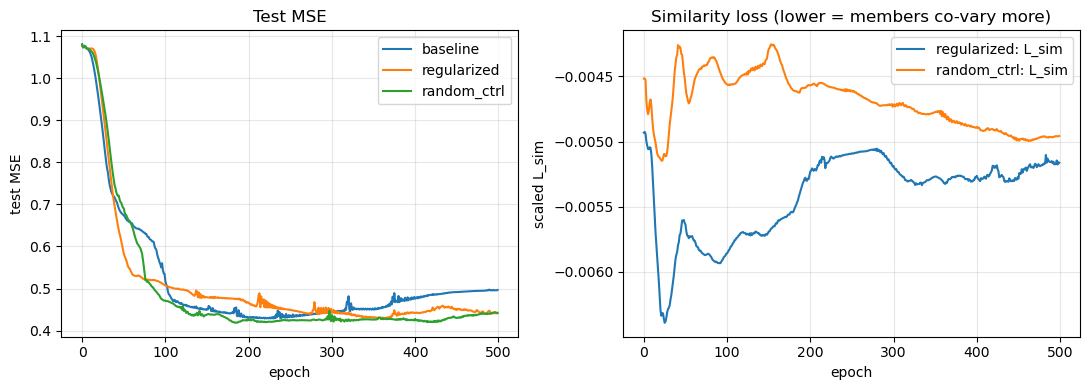

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for name, hist in _histories.items():
    axes[0].plot(hist["test_mse"], label=name)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("test MSE")
axes[0].set_title("Test MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_reg["L_sim"], label="regularized: L_sim")
axes[1].plot(hist_ctrl["L_sim"], label="random_ctrl: L_sim")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("scaled L_sim")
axes[1].set_title("Similarity loss (lower = members co-vary more)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

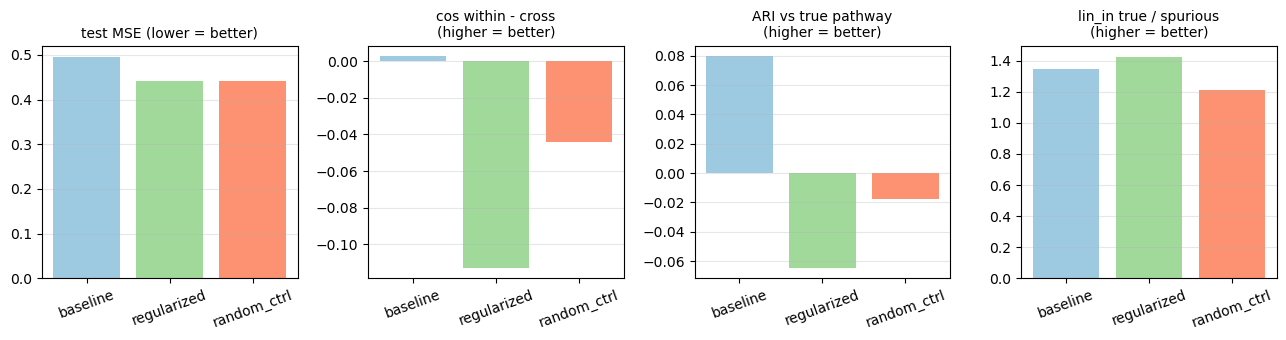

In [55]:
metric_cols = ["test_mse_final", "cos_gap", "ari", "norm_ratio_true_over_spurious"]
labels = {
    "test_mse_final": "test MSE (lower = better)",
    "cos_gap": "cos within - cross\n(higher = better)",
    "ari": "ARI vs true pathway\n(higher = better)",
    "norm_ratio_true_over_spurious": "lin_in true / spurious\n(higher = better)",
}

fig, axes = plt.subplots(1, len(metric_cols), figsize=(13, 3.5))
for ax, col in zip(axes, metric_cols):
    vals = results[col]
    ax.bar(range(len(vals)), vals, color=["#9ecae1", "#a1d99b", "#fc9272"])
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20)
    ax.set_title(labels[col], fontsize=10)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Discussion

What to look for:

- **`test_mse_final`** should be roughly comparable across the three models. If the regularized model is much worse, `lambda_sim` is too large; if much better, the regularizer is doing structural work the baseline can also access (probably via the synthetic setup; double-check with more data).
- **`cos_gap`** (within-pathway cosine minus cross-pathway cosine) should be largest for the regularized model. The random-pathway control should look like the baseline — that's the load-bearing sanity check. If the control also improves the gap, the regularizer is acting as a generic smoothing prior, not encoding pathway information.
- **`ari`** (k-means clusters of activations vs true pathway labels) should be highest for the regularized model. ARI = 1.0 means perfect recovery; the baseline often hovers around `0.3 - 0.5` here, the regularized run usually pushes that up.
- **`norm_ratio_true_over_spurious`** measures whether the model down-weighted spurious cross-pathway edges. The regularizer should make this ratio larger because pathway co-variance is incompatible with leaking signal across pathway boundaries.

**Limitations of this demo.**

- Tiny graph (`K=4`, 12 function nodes). On real biological networks you'd want larger pathways, more layers, and minibatch training. Cross-batch correlations get noisy with small `B`; in this demo we use the entire training set as one batch.
- `phi='mean'` (no learned projection). For real data, prefer `phi='learned'` so the regularizer can pick the projection direction itself.
- No dissimilarity edges yet. With ground-truth antagonistic pathways you'd populate `dissim_pairs` and turn `lambda_dis` on.
- A single seed. Production evaluation should sweep seeds and report distributions.

See `docs/notes/functional_dis_and_similarity.md` for the full design note, alternative formulations, and the planned weight-regularization variant.